# Merged `Sobol` verifying it returns equal values to the non-merged Sobol

One `Sobol` class, three model types.

Two things happen at once here, and they have to be kept apart.

**The merge.** `SobolTokenPerturbator` and `SobolImagePerturbator` had identical `get_mask`
bodies, so they collapse into one `SobolPerturbator`.

**The fix.** Both ended in `(masks < 0.5).float()`, binarizing a quasi-Monte-Carlo design that is
continuous by construction. That is correct for text — token ids are discrete, and
`TextMaskPerturbator.apply_mask` truncates to int — but wrong for images, where `perturb`
blends without rounding. The merged class takes an `is_binarized` flag, which `Sobol.__init__`
derives from `base_mask_perturbator_class`.

So that this notebook measures the merge and not the fix, `old_sobol_perturbation.py`'s image
class drops the threshold too. Its text class keeps it. The legacy image baseline here is
therefore not what the library shipped — deliberately.

The last cell checks equality.

## Disable the runtime type checks (optional)

**Must run before anything imports `jaxtyping`** — the flag is read at import time, so this
has to be the first cell executed in a fresh kernel. Comment it out to get the shape checks
back; do that before believing any actual attribution numbers, since with the checks off a
shape bug surfaces as a downstream broadcast error or not at all.

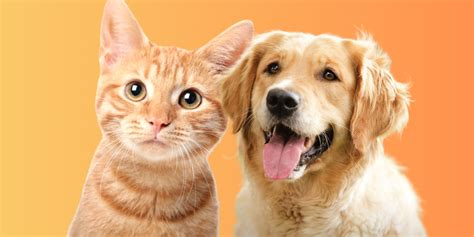

In [1]:
%matplotlib inline

from functools import partial

import torch
from PIL import Image
from scipy.stats import qmc
from transformers import (
    AutoImageProcessor,
    AutoModelForCausalLM,
    AutoModelForImageClassification,
    AutoModelForSequenceClassification,
    AutoTokenizer,
)

from interpreto.attributions.aggregations.sobol_aggregation import SobolIndicesOrders
from interpreto.attributions.methods.old_image_sobol_attribution import ImageSobol as LegacyImageSobol
from interpreto.attributions.methods.old_sobol_attribution import Sobol as LegacySobol
from interpreto.attributions.methods.sobol_attribution import Sobol
from interpreto.visualizations import plot_attributions, plot_image_attribution

sentence = "interpreto is nice"
image = Image.open("../fixtures/images/equal_cat_and_dog.jpg").convert("RGB")
image

## The three models

In [2]:
cls_model = AutoModelForSequenceClassification.from_pretrained("hf-internal-testing/tiny-random-bert")
cls_processor = AutoTokenizer.from_pretrained("hf-internal-testing/tiny-random-bert")

gen_model = AutoModelForCausalLM.from_pretrained("hf-internal-testing/tiny-random-gpt2")
gen_processor = AutoTokenizer.from_pretrained("hf-internal-testing/tiny-random-gpt2")

vit_model = AutoModelForImageClassification.from_pretrained("akahana/vit-base-cats-vs-dogs")
vit_processor = AutoImageProcessor.from_pretrained("akahana/vit-base-cats-vs-dogs")

Loading weights:   0%|          | 0/89 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: hf-internal-testing/tiny-random-bert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
qa_outputs.weight                          | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
qa_outputs.bias                            | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/64 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

## The three explainers

`n_token_perturbations` is kept small: the forward count is `(g + 2) * k`, and on a ViT with a
14x14 patch grid `g = 196`, so even `k = 4` is ~800 forwards per image.

Note the seeding. Unlike every other merge notebook, `torch.manual_seed(0)` is useless here:
Sobol's masks come from `scipy.stats.qmc`, whose samplers default to `scramble=True` and draw
from numpy's generator, which `np.random.seed` no longer controls either. So the sampler is
pinned to `scramble=False` on both sides instead, which makes the QMC design deterministic.

That is a test-harness knob, not a fix. Scrambling is what gives randomized QMC its error
estimate and what removes the unscrambled sequence's degenerate first point (the origin: an
all-zeros row of `A`). Turning it off is fine for comparing two implementations on identical
masks, and wrong anywhere else.

This is pre-existing, not something the merge introduced: Sobol has no seed argument, so it is
currently unseedable through the public API.

One more knob has to be pinned: legacy `Sobol` defaults to `FIRST_ORDER` while legacy
`ImageSobol` defaults to `TOTAL_ORDER`. The merged class keeps the text default, so the
image side changes behaviour unless the caller asks for `TOTAL_ORDER` explicitly.

In [3]:
K = 4
# The legacy text and image classes disagree on this default (FIRST_ORDER vs
# TOTAL_ORDER), so it has to be pinned or the two sides compute different estimators.
ORDER = SobolIndicesOrders.FIRST_ORDER

cls_explainer = Sobol(cls_model, cls_processor, n_token_perturbations=K, sobol_indices_order=ORDER)
gen_explainer = Sobol(gen_model, gen_processor, n_token_perturbations=K, sobol_indices_order=ORDER)
vit_explainer = Sobol(vit_model, vit_processor, n_token_perturbations=K, sobol_indices_order=ORDER)

legacy_cls_explainer = LegacySobol(cls_model, cls_processor, n_token_perturbations=K, sobol_indices_order=ORDER)
legacy_gen_explainer = LegacySobol(gen_model, gen_processor, n_token_perturbations=K, sobol_indices_order=ORDER)
legacy_vit_explainer = LegacyImageSobol(vit_model, vit_processor, n_token_perturbations=K, sobol_indices_order=ORDER)

# get_mask calls `self.sampler_class(2 * l)`, so the only way to reach the constructor from
# here is to substitute sampler_class itself.
deterministic_sampler = partial(qmc.Sobol, scramble=False)

EXPLAINERS = [
    cls_explainer,
    gen_explainer,
    vit_explainer,
    legacy_cls_explainer,
    legacy_gen_explainer,
    legacy_vit_explainer,
]
for explainer in EXPLAINERS:
    explainer.perturbator.sampler_class = deterministic_sampler

legacy_cls_outputs = legacy_cls_explainer.explain(sentence)
legacy_gen_outputs = legacy_gen_explainer.explain(sentence, targets="right")
legacy_vit_outputs = legacy_vit_explainer.explain(image)

cls_outputs = cls_explainer.explain(sentence)
gen_outputs = gen_explainer.explain(sentence, targets="right")
vit_outputs = vit_explainer.explain(image)

[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


## Checking that the new methods are equal to the old

We consider here that LegacySobol (on all task / modalities combination) is the ground truth.
We want to show that the merged Sobol method returns the same AttributionOutput /
ImageAttributionOutput as the ""Legacy""Sobol

In [4]:
def same(a, b):
    """Exact equality, counting NaN in the same position as a match."""
    return a.shape == b.shape and bool(((a == b) | (a.isnan() & b.isnan())).all())


for name, new, old in [
    ("cls", cls_outputs[0], legacy_cls_outputs[0]),
    ("gen", gen_outputs[0], legacy_gen_outputs[0]),
    ("vit", vit_outputs[0], legacy_vit_outputs[0]),
]:
    ok = same(new.attributions, old.attributions)
    print(f"{name}: {tuple(new.attributions.shape)}  {'identical' if ok else 'DIFFERENT'}")
    assert ok, f"{name}: merged attributions differ from legacy"

print("\nmerged Sobol reproduces the legacy attributions exactly")

cls: (1, 3)  identical
gen: (1, 4)  identical
vit: (1, 196)  identical

merged Sobol reproduces the legacy attributions exactly


## The masks the two modalities now produce

Direct check on the thing the fix changed: the text perturbator must still emit a mask of
exactly `{0, 1}`, and the image one must emit values spread across `[0, 1)`.

In [ ]:
cls_mask = cls_explainer.perturbator.get_mask(6)
vit_mask = vit_explainer.perturbator.get_mask(6)

print("text unique values:", torch.unique(cls_mask).tolist())
print(f"image range: [{vit_mask.min():.4f}, {vit_mask.max():.4f}], {torch.unique(vit_mask).numel()} distinct values")

assert set(torch.unique(cls_mask).tolist()) <= {0.0, 1.0}, "text masks must stay binary"
assert torch.unique(vit_mask).numel() > 2, "image masks must be continuous"

## Visualize

In [ ]:
plot_attributions(cls_outputs[0])

In [ ]:
plot_attributions(gen_outputs[0])

In [ ]:
plot_attributions(legacy_gen_outputs[0])

In [ ]:
fig, axes = plot_image_attribution(vit_outputs, alpha=0.5)